out:
 [[-0.04]
 [ 1.57]
 [ 2.02]
 [ 2.52]
 [ 2.05]
 [ 1.12]
 [ 0.4 ]
 [ 1.9 ]
 [ 0.94]]


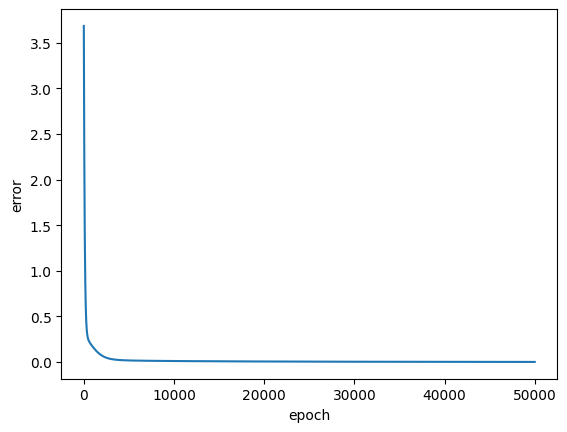

[[0.58298774]
 [1.66800214]]


In [19]:
import numpy as np
import matplotlib.pyplot as plt


def tanh(x):
    return np.tanh(x)


def tanh_d(x):
    return 1-np.tanh(x)**2


def mse(y_true, y_pred):
    return np.mean(np.power(y_true-y_pred, 2))


def mse_d(y_true, y_pred):
    return 2*(y_pred-y_true)/y_true.size

dw1_hist = []
dw2_hist = []
w1_hist = []
w2_hist = []

class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))

        self.errors = []

    def forward(self, X):
        # 前向传播
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = tanh(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        # self.a2 = tanh(self.z2)
        # return self.a2
        return self.z2

    def backward(self, X, y, output, epoch):
        # 反向传播
        m = X.shape[0]

        # 输出层误差
        d_W2 = np.zeros(self.W2.shape)
        d_b2 = np.zeros(self.b2.shape)
        self.errors.append(mse(y, output))
        # error_d = output - y
        error_d = mse_d(y, output)

        # d_z2 = error_d * tanh_d(self.z2)
        d_z2 = error_d
        d_W2 = np.dot(self.a1.T, d_z2) / m
        d_b2 = np.sum(d_z2, axis=0, keepdims=True) / m
        
        # 隐藏层误差
        d_z1 = np.dot(d_z2, self.W2.T) * tanh_d(self.z1)
        d_W1 = np.dot(X.T, d_z1) / m
        d_b1 = np.sum(d_z1, axis=0, keepdims=True) / m
        
        # if epoch % 100 == 0:
        #     print('\n', epoch, '\nerror', error, '\nd_W1', d_W1, '\nd_b1', d_b1, '\nd_W2', d_W2, '\nd_b2', d_b2)

        # 更新权重和偏置
        learning_rate = 0.01
        self.W1 -= learning_rate * d_W1
        self.b1 -= learning_rate * d_b1
        self.W2 -= learning_rate * d_W2
        self.b2 -= learning_rate * d_b2
        # print(self.W1, self.b1, self.W2, self.b2)
        
        if epoch % 1000 == 0:
            dw1_hist.append(d_W1)
            dw2_hist.append(d_W2)
            w1_hist.append(self.W1.copy())
            w2_hist.append(self.W2.copy())
            

    def train(self, X, y, epochs):
        for epoch in range(epochs):
            output = self.forward(X)
            # print(f'{epoch}:')
            self.backward(X, y, output, epoch)

    def predict(self, X):
        return self.forward(X)

    def plot_errors(self):
        plt.plot(self.errors)
        plt.xlabel("epoch")
        plt.ylabel("error")
        plt.show()


X = np.array([[0, 0], [0.3, 1], [0.6, 0.8], [1,  0.6], [0.8, 0.4], [0.4, 0.3], [0.1,  0.2], [0.5, 0.9], [0.2, 0.5]])
y = np.array([[0],    [1.6],    [2.0],      [2.6],     [2.0],      [1.1],      [0.4],       [1.9],      [0.9]])

nn = SimpleNeuralNetwork(2, 3, 1)
nn.train(X, y, epochs=50000)
print('out:\n', np.round(nn.predict(X), 2))
nn.plot_errors()

print(nn.predict(np.array([[0, 0.5], [0.6, 0.4]])))

In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation

min = np.min([np.min(dw1_hist), np.min(dw2_hist)])
max = np.max([np.max(dw1_hist), np.max(dw2_hist)])


plt.rcParams['animation.html'] = 'jshtml'
plt.ioff()

fig, (ax1, ax2) = plt.subplots(1, 2)

# dw1_hist = []
# dw2_hist = []

def animate(t):
    
    ax1.clear()
    ax2.clear()
    
    ax1.imshow(dw1_hist[t], vmin=min, vmax=max)
    ax2.imshow(dw2_hist[t], vmin=min, vmax=max)

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])


matplotlib.animation.FuncAnimation(fig, animate, frames=len(dw1_hist))
# plt.show()


In [17]:
import matplotlib.pyplot as plt
import matplotlib.animation

min = np.min([np.min(w1_hist), np.min(w2_hist)])
max = np.max([np.max(w1_hist), np.max(w2_hist)])


plt.rcParams['animation.html'] = 'jshtml'
plt.ioff()

fig, (ax1, ax2) = plt.subplots(1, 2)

# dw1_hist = []
# dw2_hist = []

def animate(t):
    
    ax1.clear()
    ax2.clear()
    
    ax1.imshow(w1_hist[t], vmin=min, vmax=max)
    ax2.imshow(w2_hist[t], vmin=min, vmax=max)

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])


matplotlib.animation.FuncAnimation(fig, animate, frames=len(w1_hist))
# plt.show()


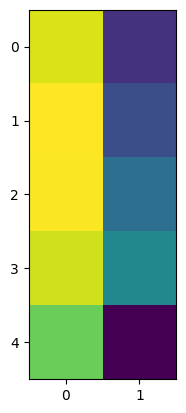

In [24]:
import matplotlib.pyplot as plt

X = np.array([[0.3, 0.4], [0.4, 0.3], [0.5, 0.2], [0.6, 0.1], [0.7, 0.5]])
Y = nn.predict(X)

num_inputs = X.shape[1]
num_outputs = Y.shape[1]

d = 0.001

J = np.zeros((len(X), num_inputs))
for i in range(num_inputs):
    X_p = X.copy()
    X_p[:, i] += d
    
    Y_p = nn.predict(X_p)
    
    J[:, i] = ((Y_p - Y) / d).reshape(5)
    
plt.imshow(J)
plt.show()